<a href="https://colab.research.google.com/github/Nishitkumar25/M/blob/main/MLproj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn import tree

In [ ]:
# Load the data
data = pd.read_csv("/content/D2-Processed-features.csv")

In [ ]:
data

,participant,question,version,viewingTimeSec,fixationCount,saccadeCount,meanFixationDuration,meanSaccadeDuration,meanPupilDiamater,meanPupilDiamaterFixation,minFixationDuration,maxFixationDuration,minSaccadeDuration,maxSaccadeDuration,viewingTimeSec_S2,believability
0,1,1,fake,8.023,28,31,239.250,32.710,0.832,0.831,87,480,15,60,13.022,4
1,1,2,TRUE,10.023,36,41,231.639,29.000,0.841,0.841,72,575,15,52,16.057,5
2,1,3,fake,18.012,66,75,228.621,28.173,0.867,0.866,67,640,2,78,14.063,2
3,1,4,fake,17.060,63,72,227.841,28.333,0.821,0.821,63,598,10,58,17.050,4
4,1,5,fake,22.082,78,85,245.718,26.741,0.852,0.851,77,597,12,72,15.025,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,27,56,fake,12.063,49,55,201.000,32.382,0.665,0.665,75,592,2,68,13.030,4
1445,27,57,TRUE,12.028,49,56,204.714,29.268,0.689,0.689,113,427,8,60,18.088,3
1446,27,58,TRUE,5.963,24,28,187.542,30.571,0.669,0.670,117,373,7,68,13.015,4
1447,27,59,fake,13.003,52,58,199.500,30.328,0.663,0.663,62,405,7,72,13.038,4


In [ ]:
# Check for missing values
data.isnull().sum()

,0
participant,0
question,0
version,0
viewingTimeSec,0
fixationCount,0
saccadeCount,0
meanFixationDuration,0
meanSaccadeDuration,0
meanPupilDiamater,0
meanPupilDiamaterFixation,0


In [ ]:
data.max()

,0
participant,27
question,60
version,fake
viewingTimeSec,55.247
fixationCount,207
saccadeCount,275
meanFixationDuration,379.288
meanSaccadeDuration,47.9
meanPupilDiamater,0.894
meanPupilDiamaterFixation,0.894


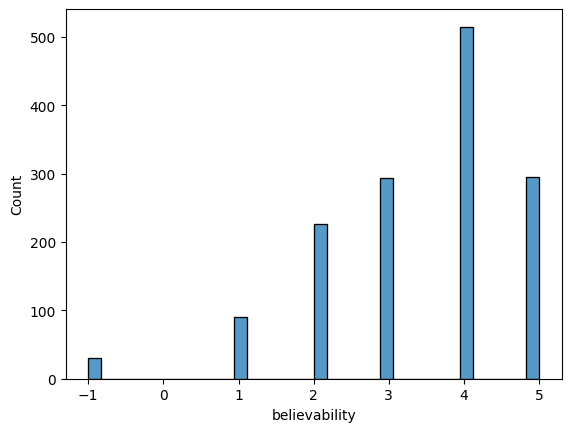

In [ ]:
#histogram of the target variable
sns.histplot(data['believability'])
plt.show()

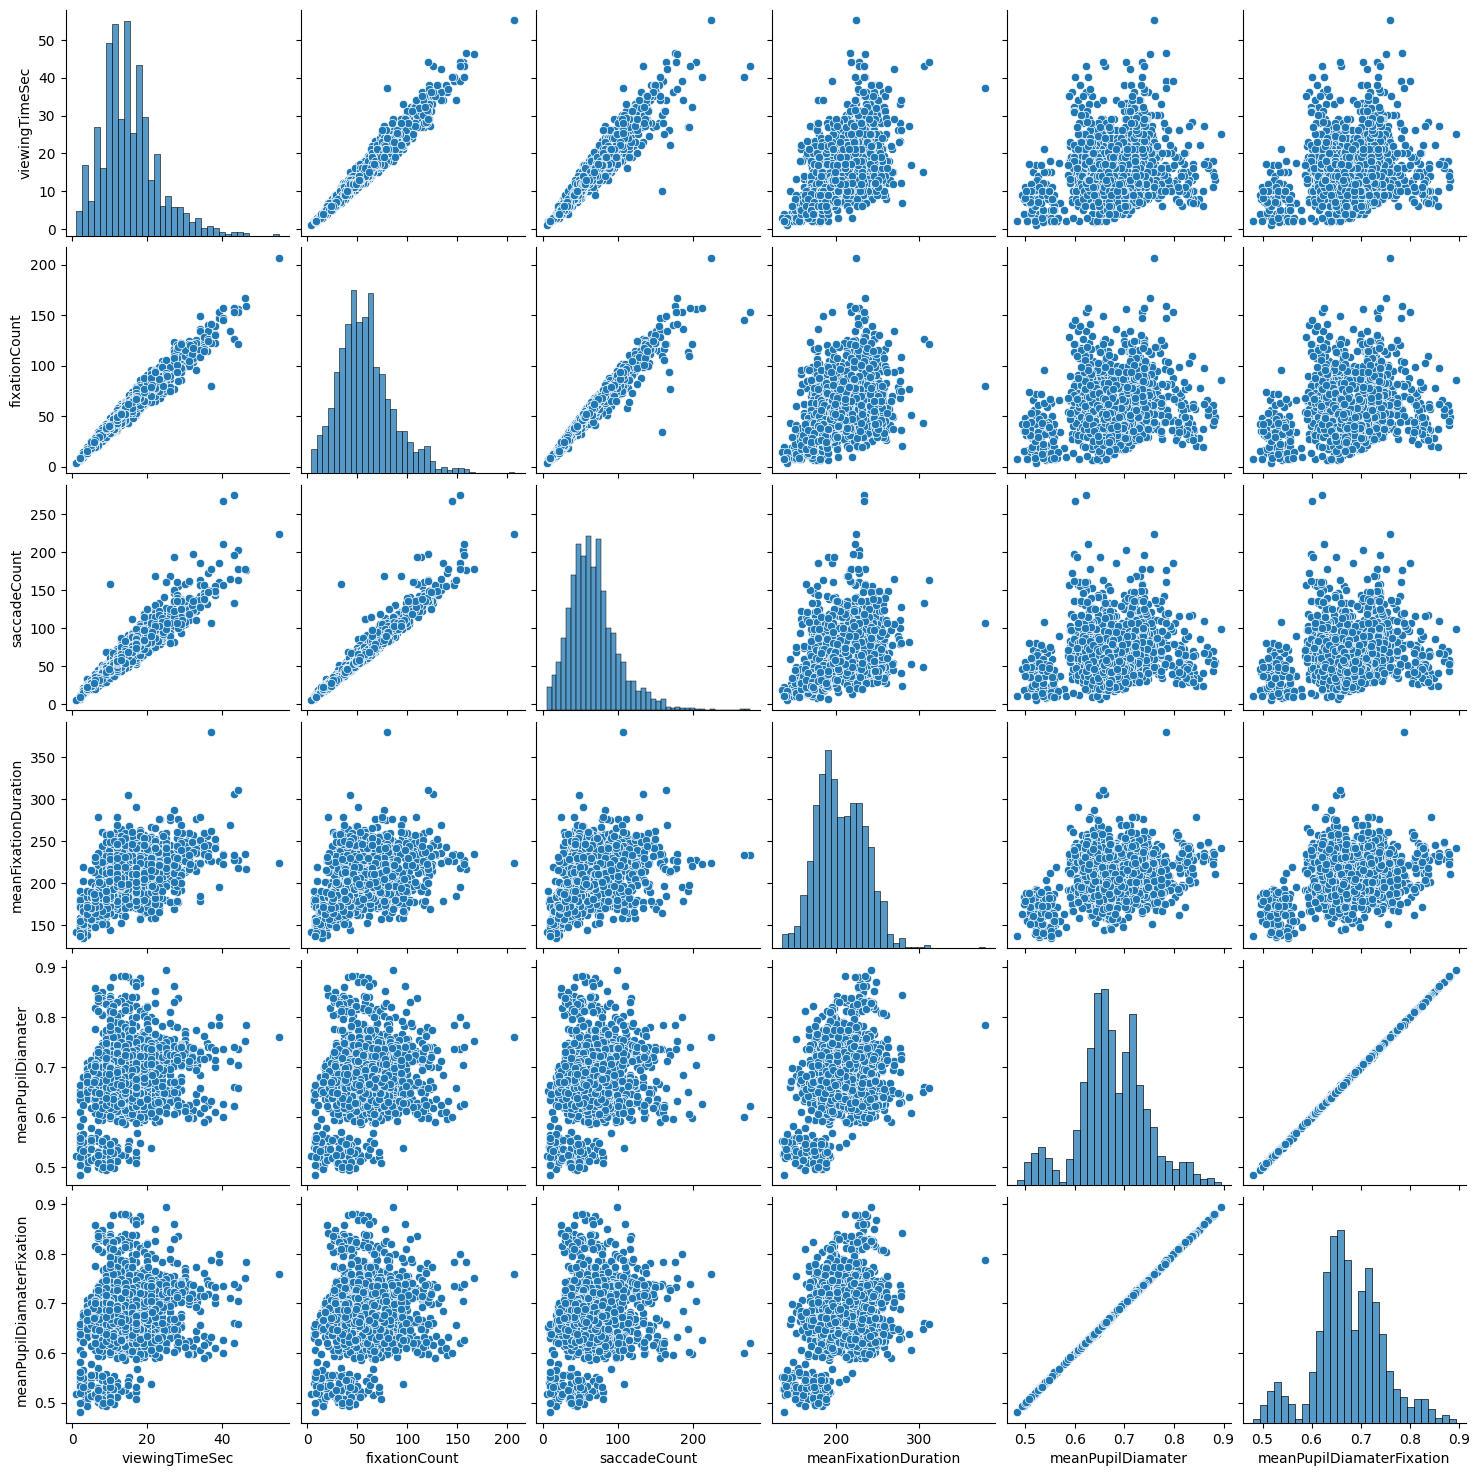

In [ ]:
sns.pairplot(data[['viewingTimeSec','fixationCount','saccadeCount','meanFixationDuration','meanPupilDiamater','meanPupilDiamaterFixation']])
plt.show()

In [ ]:
data['version'] = data['version'].map({'fake': 0, 'TRUE': 1})

In [ ]:
#dataset division training and testing
X = data.drop(['participant','believability'], axis=1)
y = data['believability']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_lin_pred = lin_reg.predict(X_test)

In [ ]:
knnClassifier = KNeighborsClassifier(n_neighbors=5)
knnClassifier.fit(X_train, y_train)
y_knn_pred = knnClassifier.predict(X_test)

In [ ]:
#K means clustering
kmeans = KMeans(n_clusters=2)
kmeans.fit(X_train)
y_kmeans_pred = kmeans.predict(X_test)

In [ ]:
# Mean Squared Error lin_reg
print(mean_squared_error(y_test, y_lin_pred))
# R2 Score lin_reg
print(r2_score(y_test, y_lin_pred))

# Mean Squared Error knn
print(mean_squared_error(y_test, y_knn_pred))
# R2 Score knn
print(r2_score(y_test, y_knn_pred))
#knn score
print(knnClassifier.score(X_test, y_test))


# Mean Squared Error kmeans
print(mean_squared_error(y_test, y_kmeans_pred))
# R2 Score kmeans
print(r2_score(y_test, y_kmeans_pred))

1.7393881694410183
0.04959494107182072
3.717241379310345
-1.0311078770238313
0.2413793103448276
13.296551724137931
-6.265261571246655


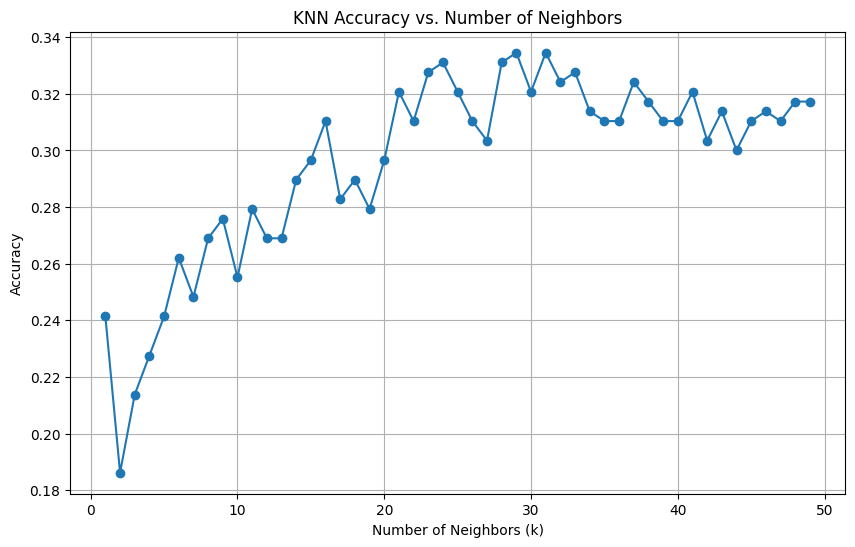

In [ ]:
#accuracy plot with 1 to 11 knn
k_values = range(1, 50)
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.title('KNN Accuracy vs. Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# Assuming X and y are already defined
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit the model on the training data
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict the labels for both training and test data
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

# Compute the confusion matrix for training data
conf_matrix_train = confusion_matrix(y_train, y_train_pred)
print("Confusion Matrix (Training Data):")
print(conf_matrix_train)

# Compute the confusion matrix for test data
conf_matrix_test = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix (Test Data):")
print(conf_matrix_test)

# Compute the classification report for training data
class_report_train = classification_report(y_train, y_train_pred)
print("Classification Report (Training Data):")
print(class_report_train)

# Compute the classification report for test data
class_report_test = classification_report(y_test, y_test_pred)
print("Classification Report (Test Data):")
print(class_report_test)

Confusion Matrix (Training Data):
[[  9   1   2   3   3   1]
 [  3  42   4   2   7   4]
 [  4  16 108   6  23   2]
 [  4  12  38 100  33   9]
 [  6  23  50  54 216  23]
 [  5  25  36  31  19  90]]
Confusion Matrix (Test Data):
[[ 0  0  2  2  3  4]
 [ 1  2  8  9  3  5]
 [ 5  8 12 11 19 12]
 [ 5 14 14 25 30  9]
 [ 3 12 33 27 47 21]
 [ 6  8 26 14 23 12]]
Classification Report (Training Data):
              precision    recall  f1-score   support

          -1       0.29      0.47      0.36        19
           1       0.35      0.68      0.46        62
           2       0.45      0.68      0.54       159
           3       0.51      0.51      0.51       196
           4       0.72      0.58      0.64       372
           5       0.70      0.44      0.54       206

    accuracy                           0.56      1014
   macro avg       0.50      0.56      0.51      1014
weighted avg       0.60      0.56      0.56      1014

Classification Report (Test Data):
              precision    re

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid for k values
param_grid = {'n_neighbors': range(1, 51)}

# Initialize the GridSearchCV with the KNN classifier and the parameter grid
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')

# Fit the model to the training data
grid_search.fit(X_train, y_train)

# Retrieve the best parameters and the best score
best_k = grid_search.best_params_['n_neighbors']
best_score = grid_search.best_score_

print(f"Best k value: {best_k}")
print(f"Best cross-validated accuracy: {best_score:.4f}")

Best k value: 49
Best cross-validated accuracy: 0.3590


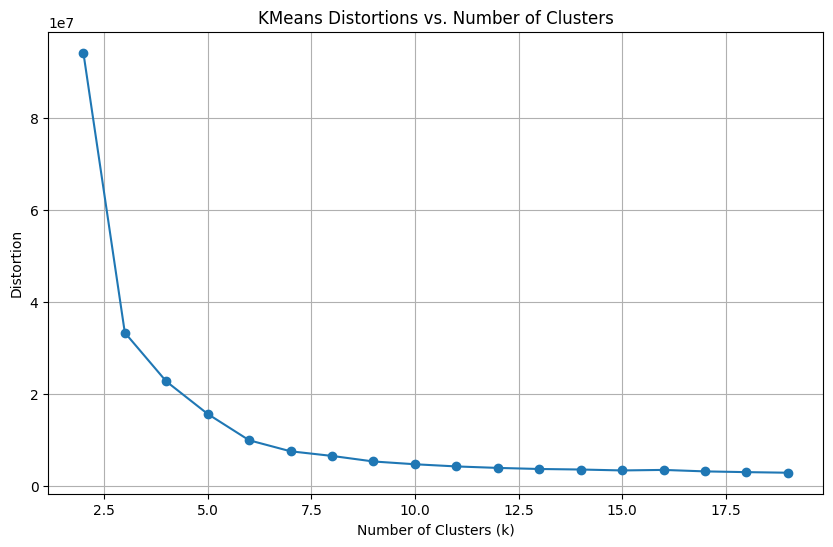

In [ ]:
distortions = []
for k in range(2, 20):
    kmeans = KMeans(n_clusters=k).fit(X_train)
    distortions.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 20), distortions, marker='o')
plt.title('KMeans Distortions vs. Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize the Perceptron model
perceptron = Perceptron()

# Fit the model to the training data
perceptron.fit(X_train, y_train)

# Predict the labels for the test data
y_perceptron_pred = perceptron.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_perceptron_pred)
conf_matrix = confusion_matrix(y_test, y_perceptron_pred)
class_report = classification_report(y_test, y_perceptron_pred, zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.3287
Confusion Matrix:
[[  0   0   0   0  11   0]
 [  0   0   0   0  28   0]
 [  0   0   0   0  67   0]
 [  0   0   0   0  97   0]
 [  0   0   0   0 143   0]
 [  0   0   0   0  89   0]]
Classification Report:
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        11
           1       0.00      0.00      0.00        28
           2       0.00      0.00      0.00        67
           3       0.00      0.00      0.00        97
           4       0.33      1.00      0.49       143
           5       0.00      0.00      0.00        89

    accuracy                           0.33       435
   macro avg       0.05      0.17      0.08       435
weighted avg       0.11      0.33      0.16       435



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define the parameter grid
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150,)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.05],
    'learning_rate': ['constant', 'adaptive'],
}

# Initialize the GridSearchCV with the MLPClassifier and the parameter grid
grid_search = GridSearchCV(MLPClassifier(max_iter=300, random_state=42), param_grid, cv=5, scoring='accuracy')

# Fit the model to the training data
grid_search.fit(X_train, y_train)

# Retrieve the best parameters and the best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters: {best_params}")
print(f"Best cross-validated accuracy: {best_score:.4f}")

# Train the model with the best parameters
mlp = grid_search.best_estimator_
mlp.fit(X_train, y_train)

# Predict the labels for the test data
y_mlp_pred = mlp.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_mlp_pred)
conf_matrix = confusion_matrix(y_test, y_mlp_pred)
class_report = classification_report(y_test, y_mlp_pred, zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

Best parameters: {'activation': 'tanh', 'alpha': 0.05, 'hidden_layer_sizes': (150,), 'learning_rate': 'constant', 'solver': 'sgd'}
Best cross-validated accuracy: 0.3678
Accuracy: 0.3287
Confusion Matrix:
[[  0   0   0   1  10   0]
 [  0   0   0   0  28   0]
 [  0   0   0   1  66   0]
 [  0   0   0   0  97   0]
 [  0   0   0   0 143   0]
 [  0   0   0   0  89   0]]
Classification Report:
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        11
           1       0.00      0.00      0.00        28
           2       0.00      0.00      0.00        67
           3       0.00      0.00      0.00        97
           4       0.33      1.00      0.50       143
           5       0.00      0.00      0.00        89

    accuracy                           0.33       435
   macro avg       0.06      0.17      0.08       435
weighted avg       0.11      0.33      0.16       435



In [ ]:
#descision gini tree
gini = tree.DecisionTreeClassifier()
gini.fit(X_train,y_train)
y_tree_pred = gini.predict(X_test)
accuracy = accuracy_score(y_test,y_tree_pred)
print(f"Tree Accuracy: {accuracy:.4f}")
# tree.plot_tree(gini)

Tree Accuracy: 0.2391


In [ ]:
#descision entropy tree
entropy = tree.DecisionTreeClassifier(criterion="entropy", max_depth=3)
entropy.fit(X_train,y_train)
y_entropy_pred = entropy.predict(X_test)
accuracy = accuracy_score(y_test,y_entropy_pred)
print(f"Tree Accuracy: {accuracy:.4f}")
# tree.plot_tree(gini)

Tree Accuracy: 0.3356


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler to ensure non-negative features for MultinomialNB
scaler = MinMaxScaler()

# Scale the training and test features to the range [0, 1]
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Multinomial Naive Bayes model
mnb = MultinomialNB()

# Fit the model to the scaled training data
mnb.fit(X_train_scaled, y_train)

# Predict the labels for the scaled test data
y_mnb_pred = mnb.predict(X_test_scaled)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_mnb_pred)
conf_matrix = confusion_matrix(y_test, y_mnb_pred)
class_report = classification_report(y_test, y_mnb_pred, zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)


Accuracy: 0.3287
Confusion Matrix:
[[  0   0   0   0  11   0]
 [  0   0   0   0  28   0]
 [  0   0   0   0  67   0]
 [  0   0   0   0  97   0]
 [  0   0   0   0 143   0]
 [  0   0   0   0  89   0]]
Classification Report:
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        11
           1       0.00      0.00      0.00        28
           2       0.00      0.00      0.00        67
           3       0.00      0.00      0.00        97
           4       0.33      1.00      0.49       143
           5       0.00      0.00      0.00        89

    accuracy                           0.33       435
   macro avg       0.05      0.17      0.08       435
weighted avg       0.11      0.33      0.16       435



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler to scale the data for SVM (SVMs perform better with scaled data)
scaler = StandardScaler()

# Scale the training and test features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Support Vector Classifier (SVC)
svm_model = SVC(kernel='linear')  # You can choose different kernels like 'linear', 'rbf', 'poly'

# Fit the model to the scaled training data
svm_model.fit(X_train_scaled, y_train)

# Predict the labels for the scaled test data
y_svm_pred = svm_model.predict(X_test_scaled)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_svm_pred)
conf_matrix = confusion_matrix(y_test, y_svm_pred)
class_report = classification_report(y_test, y_svm_pred, zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)


Accuracy: 0.3287
Confusion Matrix:
[[  0   0   0   0  11   0]
 [  0   0   0   0  28   0]
 [  0   0   0   0  67   0]
 [  0   0   0   0  97   0]
 [  0   0   0   0 143   0]
 [  0   0   0   0  89   0]]
Classification Report:
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        11
           1       0.00      0.00      0.00        28
           2       0.00      0.00      0.00        67
           3       0.00      0.00      0.00        97
           4       0.33      1.00      0.49       143
           5       0.00      0.00      0.00        89

    accuracy                           0.33       435
   macro avg       0.05      0.17      0.08       435
weighted avg       0.11      0.33      0.16       435



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model to the training data
rf.fit(X_train, y_train)

# Predict the labels for the test data
y_rf_pred = rf.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_rf_pred)
conf_matrix = confusion_matrix(y_test, y_rf_pred)
class_report = classification_report(y_test, y_rf_pred, zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)


Accuracy: 0.3172
Confusion Matrix:
[[  0   0   0   4   6   1]
 [  0   0   2   6  16   4]
 [  0   1   2   9  50   5]
 [  0   0   6  14  67  10]
 [  0   0   5  16 101  21]
 [  0   0   3   8  57  21]]
Classification Report:
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        11
           1       0.00      0.00      0.00        28
           2       0.11      0.03      0.05        67
           3       0.25      0.14      0.18        97
           4       0.34      0.71      0.46       143
           5       0.34      0.24      0.28        89

    accuracy                           0.32       435
   macro avg       0.17      0.19      0.16       435
weighted avg       0.25      0.32      0.26       435



In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize the LDA model
lda = LinearDiscriminantAnalysis()

# Fit the model to the training data
lda.fit(X_train, y_train)

# Predict the labels for the test data
y_lda_pred = lda.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_lda_pred)
conf_matrix = confusion_matrix(y_test, y_lda_pred)
class_report = classification_report(y_test, y_lda_pred, zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)


Accuracy: 0.2920
Confusion Matrix:
[[  0   0   0   1   9   1]
 [  0   0   2   4  20   2]
 [  0   0   2  12  47   6]
 [  0   0   2   8  81   6]
 [  0   0   3  11 108  21]
 [  0   0   3   1  76   9]]
Classification Report:
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        11
           1       0.00      0.00      0.00        28
           2       0.17      0.03      0.05        67
           3       0.22      0.08      0.12        97
           4       0.32      0.76      0.45       143
           5       0.20      0.10      0.13        89

    accuracy                           0.29       435
   macro avg       0.15      0.16      0.13       435
weighted avg       0.22      0.29      0.21       435



In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assume X_train, X_test are already sequences
# Reshape the data to 3D input for LSTM [samples, timesteps, features]
X_train_reshaped = np.expand_dims(X_train, axis=-1)
X_test_reshaped = np.expand_dims(X_test, axis=-1)

# Convert the labels to categorical using label encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Initialize the LSTM model
model = Sequential()
model.add(LSTM(100, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]), activation='tanh'))
model.add(Dense(1, activation='sigmoid'))  # Use sigmoid for binary classification, softmax for multi-class

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model to the training data
model.fit(X_train_reshaped, y_train_encoded, epochs=10, batch_size=32, verbose=1)

# Predict the labels for the test data
y_lstm_pred = (model.predict(X_test_reshaped) > 0.5).astype(int)

# Evaluate the model's performance
accuracy = accuracy_score(y_test_encoded, y_lstm_pred)
conf_matrix = confusion_matrix(y_test_encoded, y_lstm_pred)
class_report = classification_report(y_test_encoded, y_lstm_pred, zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0631 - loss: -5.6033
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0650 - loss: -22.2406
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0648 - loss: -37.2789
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0604 - loss: -48.7704
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0642 - loss: -57.3171
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0611 - loss: -64.6677
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0570 - loss: -75.0325
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0636 - loss: -84.8998
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0709 - loss: -89.3589
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0634 - loss: -99.9471
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Accuracy: 0.0644
Confusion Matrix:
[[  0  11   0   0   0   0]
 [  0  28   0   0   0   0]
 [  0  67   

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Reshape the data to 3D input for GRU [samples, timesteps, features]
X_train_reshaped = np.expand_dims(X_train, axis=-1)
X_test_reshaped = np.expand_dims(X_test, axis=-1)

# Convert the labels to categorical using label encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Initialize the GRU model
model = Sequential()
model.add(GRU(100, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]), activation='tanh'))
model.add(Dense(1, activation='sigmoid'))  # Use sigmoid for binary classification, softmax for multi-class

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model to the training data
model.fit(X_train_reshaped, y_train_encoded, epochs=10, batch_size=32, verbose=1)

# Predict the labels for the test data
y_gru_pred = (model.predict(X_test_reshaped) > 0.5).astype(int)

# Evaluate the model's performance
accuracy = accuracy_score(y_test_encoded, y_gru_pred)
conf_matrix = confusion_matrix(y_test_encoded, y_gru_pred)
class_report = classification_report(y_test_encoded, y_gru_pred, zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0688 - loss: -7.3755
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0573 - loss: -29.7808
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0457 - loss: -41.1021
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0571 - loss: -50.6490
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0657 - loss: -57.5156
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0584 - loss: -65.5838
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0496 - loss: -74.5967
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0496 - loss: -83.2395
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0571 - loss: -92.5611
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0572 - loss: -98.9408
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Accuracy: 0.0644
Confusion Matrix:
[[  0  11   0   0   0   0]
 [  0  28   0   0   0   0]
 [  0  67   